# **Setup Library**

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats

# **Load Data**

In [47]:
# @title data responden kuisioner
url_r = 'https://raw.githubusercontent.com/naiarch/Big-Data-Watsons-Sociolla-Terabytes/main/Responden%20Terabyte%20-%20Form%20Responses%201.csv'
df_r = pd.read_csv(url_r)

df_r.columns = [
    'timestamp', 'nama', 'gender', 'usia', 'spending', 'toko_digunakan',
    'w_kelengkapan', 'w_miss', 'w_review', 'w_diskon', 'w_rating', 'col11',
    'w_terjual', 'w_kategori',
    's_kelengkapan', 's_miss', 's_review', 's_diskon', 's_rating', 's_terjual',
    's_kategori', 'rekomendasi_toko', 'score', 'email'
]

df_r = df_r.drop(columns=['timestamp', 'nama', 'col11', 'email'])

df_r

,gender,usia,spending,toko_digunakan,w_kelengkapan,w_miss,w_review,w_diskon,w_rating,w_terjual,w_kategori,s_kelengkapan,s_miss,s_review,s_diskon,s_rating,s_terjual,s_kategori,rekomendasi_toko,score
0,Laki-laki,18–24 tahun,< Rp100.000,Watsons,1.0,1.0,3.0,2.0,1.0,1.0,Produk rambut dan tubuh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Watsons,NaN
1,Laki-laki,< 18 tahun,< Rp100.000,Watsons,1.0,3.0,2.0,1.0,1.0,1.0,Produk rambut dan tubuh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Watsons,NaN
2,Perempuan,18–24 tahun,Rp100.000 – Rp300.000,Watsons,1.0,1.0,1.0,1.0,1.0,1.0,Produk farmasi/obat-obatan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Watsons,NaN
3,Laki-laki,18–24 tahun,< Rp100.000,Watsons,1.0,3.0,1.0,1.0,1.0,1.0,Produk rambut dan tubuh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Watsons,NaN
4,Perempuan,18–24 tahun,< Rp100.000,Sociolla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,3.0,2.0,2.0,2.0,Skincare/makeup,Sociolla,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Perempuan,18–24 tahun,Rp100.000 – Rp300.000,Sociolla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,3.0,3.0,3.0,3.0,Skincare/makeup,Sociolla,NaN
146,Perempuan,18–24 tahun,Rp100.000 – Rp300.000,Sociolla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,2.0,1.0,4.0,4.0,4.0,"Skincare/makeup, Produk rambut dan tubuh",Sociolla,NaN
147,Perempuan,18–24 tahun,Rp100.000 – Rp300.000,Sociolla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,1.0,3.0,3.0,3.0,"Skincare/makeup, Produk rambut dan tubuh",Sociolla,NaN
148,Perempuan,18–24 tahun,Rp600.001 – Rp1.000.000,Sociolla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,4.0,3.0,4.0,3.0,"Skincare/makeup, Produk rambut dan tubuh",Sociolla,NaN


In [48]:
# @title data scraping (merged)
url_m = 'https://raw.githubusercontent.com/naiarch/Big-Data-Watsons-Sociolla-Terabytes/main/merged_watsons_sociolla.csv'
df_m = pd.read_csv(url_m)

df_m

,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,sumber
0,DERMACTION PLUS Potent Triple Vitamin C Whip F...,45900.0,91900.0,50.0,5.000000,3.0,NaN,Watsons
1,WATSONS Micellar Water Hydra 500ml,44900.0,99900.0,55.0,5.000000,2.0,NaN,Watsons
2,WATSONS Micellar Water Hydra 100ml,20900.0,29900.0,30.0,NaN,0.0,NaN,Watsons
3,COLLAGEN BY WATSONS Hydro Balance Aqua Balm 9g,202900.0,289900.0,30.0,NaN,0.0,NaN,Watsons
4,WATSONS Girlish Gentle & Mild Micellar Cleansi...,39900.0,99900.0,60.0,5.000000,84.0,NaN,Watsons
...,...,...,...,...,...,...,...,...
16646,Ambre Noir Eau De Toilette,659000.0,659000.0,NaN,4.476190,7.0,7.0,Sociolla
16647,Soin Stimulating Conditioner,199000.0,199000.0,NaN,4.638889,9.0,9.0,Sociolla
16648,Repair Hair Mask,289000.0,289000.0,NaN,4.750000,5.0,5.0,Sociolla
16649,Hand Cream Olive Petitgrain,109000.0,109000.0,NaN,4.968750,8.0,8.0,Sociolla


# **Analisis Daya Beli vs Realitas Harga (*Willingness to Pay vs Actual Pricing*)**



---

> Analisis ini dilakukan untuk mengevaluasi tingkat keselarasan antara anggaran yang dialokasikan oleh konsumen (*Willingness to Pay* atau WTP) berdasarkan data kuesioner, dengan realitas harga produk yang tersedia di katalog belanja (*Actual Pricing*) dari hasil scraping data. Evaluasi dilakukan secara komparatif antara 2 platform kecantikan, yaitu Watsons dan Sociolla, untuk mengidentifikasi adanya gap atau peluang optimalisasi strategi penetapan harga.


In [49]:
# standarisasi rentang harga aktual (data scraping) menjadi tier yang sama dengan data responden kuisioner
def categorize_price(price):
    if pd.isna(price): return None
    if price <= 100000: return '< Rp100.000'
    elif price <= 300000: return 'Rp100.000 - Rp300.000'
    elif price <= 600000: return 'Rp300.000 - Rp600.000'
    elif price <= 1000000: return 'Rp600.000 - Rp1.000.000'
    else: return '> Rp1.000.000'

df_m['tier_harga'] = df_m['harga'].apply(categorize_price)

df_m

,nama_produk,harga,harga_original,diskon,rating,jumlah_review,jumlah_terjual,sumber,tier_harga
0,DERMACTION PLUS Potent Triple Vitamin C Whip F...,45900.0,91900.0,50.0,5.000000,3.0,NaN,Watsons,< Rp100.000
1,WATSONS Micellar Water Hydra 500ml,44900.0,99900.0,55.0,5.000000,2.0,NaN,Watsons,< Rp100.000
2,WATSONS Micellar Water Hydra 100ml,20900.0,29900.0,30.0,NaN,0.0,NaN,Watsons,< Rp100.000
3,COLLAGEN BY WATSONS Hydro Balance Aqua Balm 9g,202900.0,289900.0,30.0,NaN,0.0,NaN,Watsons,Rp100.000 - Rp300.000
4,WATSONS Girlish Gentle & Mild Micellar Cleansi...,39900.0,99900.0,60.0,5.000000,84.0,NaN,Watsons,< Rp100.000
...,...,...,...,...,...,...,...,...,...
16646,Ambre Noir Eau De Toilette,659000.0,659000.0,NaN,4.476190,7.0,7.0,Sociolla,Rp600.000 - Rp1.000.000
16647,Soin Stimulating Conditioner,199000.0,199000.0,NaN,4.638889,9.0,9.0,Sociolla,Rp100.000 - Rp300.000
16648,Repair Hair Mask,289000.0,289000.0,NaN,4.750000,5.0,5.0,Sociolla,Rp100.000 - Rp300.000
16649,Hand Cream Olive Petitgrain,109000.0,109000.0,NaN,4.968750,8.0,8.0,Sociolla,Rp100.000 - Rp300.000


In [50]:
# standarisasi teks kolom 'spending' dari data kuisioner
def clean_spending(val):
    val = str(val).replace('–', '-').replace(' ', '')
    if '<100' in val: return '< Rp100.000'
    elif '100' in val and '300' in val: return 'Rp100.000 - Rp300.000'
    elif '300' in val and '600' in val: return 'Rp300.000 - Rp600.000'
    elif '600' in val and '1.000' in val: return 'Rp600.000 - Rp1.000.000'
    elif '>1.000' in val: return '> Rp1.000.000'
    return val

df_r['tier_spending'] = df_r['spending'].apply(clean_spending)

df_r

,gender,usia,spending,toko_digunakan,w_kelengkapan,w_miss,w_review,w_diskon,w_rating,w_terjual,...,s_kelengkapan,s_miss,s_review,s_diskon,s_rating,s_terjual,s_kategori,rekomendasi_toko,score,tier_spending
0,Laki-laki,18–24 tahun,< Rp100.000,Watsons,1.0,1.0,3.0,2.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Watsons,NaN,<Rp100.000
1,Laki-laki,< 18 tahun,< Rp100.000,Watsons,1.0,3.0,2.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Watsons,NaN,<Rp100.000
2,Perempuan,18–24 tahun,Rp100.000 – Rp300.000,Watsons,1.0,1.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Watsons,NaN,Rp100.000 - Rp300.000
3,Laki-laki,18–24 tahun,< Rp100.000,Watsons,1.0,3.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Watsons,NaN,<Rp100.000
4,Perempuan,18–24 tahun,< Rp100.000,Sociolla,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,2.0,3.0,2.0,2.0,2.0,Skincare/makeup,Sociolla,NaN,<Rp100.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,Perempuan,18–24 tahun,Rp100.000 – Rp300.000,Sociolla,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,3.0,3.0,Skincare/makeup,Sociolla,NaN,Rp100.000 - Rp300.000
146,Perempuan,18–24 tahun,Rp100.000 – Rp300.000,Sociolla,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,2.0,1.0,4.0,4.0,4.0,"Skincare/makeup, Produk rambut dan tubuh",Sociolla,NaN,Rp100.000 - Rp300.000
147,Perempuan,18–24 tahun,Rp100.000 – Rp300.000,Sociolla,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,2.0,1.0,3.0,3.0,3.0,"Skincare/makeup, Produk rambut dan tubuh",Sociolla,NaN,Rp100.000 - Rp300.000
148,Perempuan,18–24 tahun,Rp600.001 – Rp1.000.000,Sociolla,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,4.0,3.0,4.0,3.0,"Skincare/makeup, Produk rambut dan tubuh",Sociolla,NaN,Rp600.000 - Rp1.000.000


In [51]:
# persentase WTP (Willingness to Pay) dari responden per platform
wtp_w = df_r[df_r['rekomendasi_toko'] == 'Watsons']['tier_spending'].value_counts(normalize=True) * 100
wtp_s = df_r[df_r['rekomendasi_toko'] == 'Sociolla']['tier_spending'].value_counts(normalize=True) * 100

# persentase harga aktual produk per platform
act_w = df_m[df_m['sumber'] == 'Watsons']['tier_harga'].value_counts(normalize=True) * 100
act_s = df_m[df_m['sumber'] == 'Sociolla']['tier_harga'].value_counts(normalize=True) * 100

tiers = ['< Rp100.000', 'Rp100.000 - Rp300.000', 'Rp300.000 - Rp600.000', 'Rp600.000 - Rp1.000.000', '> Rp1.000.000']

df_plot = pd.DataFrame({
    'WTP_Watsons': wtp_w,
    'Actual_Watsons': act_w,
    'WTP_Sociolla': wtp_s,
    'Actual_Sociolla': act_s
}).reindex(tiers).fillna(0)

print("TABEL GAP ANALYSIS (WTP vs ACTUAL PRICING)")
display(df_plot.round(2))

TABEL GAP ANALYSIS (WTP vs ACTUAL PRICING)


,WTP_Watsons,Actual_Watsons,WTP_Sociolla,Actual_Sociolla
< Rp100.000,0.00,60.78,0.00,35.54
Rp100.000 - Rp300.000,53.03,33.87,55.95,44.79
Rp300.000 - Rp600.000,10.61,4.22,16.67,15.53
Rp600.000 - Rp1.000.000,1.52,0.79,5.95,3.00
> Rp1.000.000,0.00,0.35,0.00,1.14


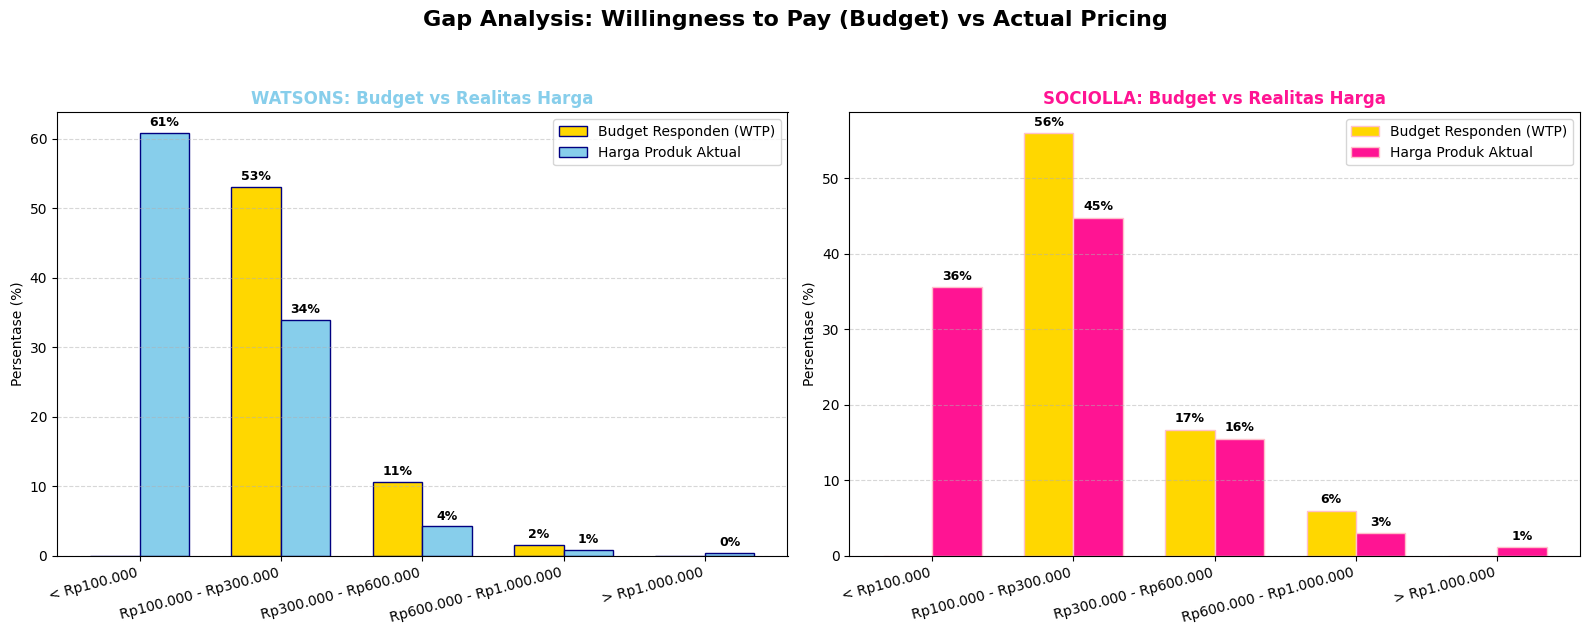

In [52]:
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Gap Analysis: Willingness to Pay (Budget) vs Actual Pricing', fontsize=16, fontweight='bold', y=1.05)

colors_w = ['#FFD700', 'skyblue']
colors_s = ['#FFD700', 'deeppink']

x = np.arange(len(tiers))
width = 0.35

# watsons
axes[0].bar(x - width/2, df_plot['WTP_Watsons'], width, label='Budget Responden (WTP)', color=colors_w[0], edgecolor='navy')
axes[0].bar(x + width/2, df_plot['Actual_Watsons'], width, label='Harga Produk Aktual', color=colors_w[1], edgecolor='navy')
axes[0].set_title('WATSONS: Budget vs Realitas Harga', fontweight='bold', color=colors_w[1])
axes[0].set_xticks(x)
axes[0].set_xticklabels(tiers, rotation=15, ha='right')
axes[0].set_ylabel('Persentase (%)')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(df_plot['WTP_Watsons']):
    if v > 0: axes[0].text(i - width/2, v + 1, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
for i, v in enumerate(df_plot['Actual_Watsons']):
    if v > 0: axes[0].text(i + width/2, v + 1, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')

# sociolla
axes[1].bar(x - width/2, df_plot['WTP_Sociolla'], width, label='Budget Responden (WTP)', color=colors_s[0], edgecolor='pink')
axes[1].bar(x + width/2, df_plot['Actual_Sociolla'], width, label='Harga Produk Aktual', color=colors_s[1], edgecolor='pink')
axes[1].set_title('SOCIOLLA: Budget vs Realitas Harga', fontweight='bold', color=colors_s[1])
axes[1].set_xticks(x)
axes[1].set_xticklabels(tiers, rotation=15, ha='right')
axes[1].set_ylabel('Persentase (%)')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(df_plot['WTP_Sociolla']):
    if v > 0: axes[1].text(i - width/2, v + 1, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')
for i, v in enumerate(df_plot['Actual_Sociolla']):
    if v > 0: axes[1].text(i + width/2, v + 1, f'{v:.0f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Gap Analysis - Watsons**

> Katalog produk Watsons memperlihatkan kecenderungan distribusi harga yang sangat agresif pada kelompok harga rendah, namun terdapat ketidaksesuaian yang cukup signifikan dengan preferensi daya beli konsumen mereka.

1. Tier < Rp100.000: Terdapat gap yang sangat kontras pada segmen ini. Sebanyak 60,78% dari total produk yang tersedia di Watsons berada di bawah Rp100.000. Sebaliknya, 0,00% responden kuesioner yang merekomendasikan Watsons memilih opsi ini sebagai batas maksimal pengeluaran mereka. Hal ini menunjukkan bahwa portofolio produk Watsons sangat didominasi oleh barang ultra-affordable, jauh di bawah batas atas daya beli optimal konsumennya.

2. Tier Rp100.000 - Rp300.000: Segmen ini merupakan zona permintaan tertinggi bagi konsumen Watsons, di mana mayoritas responden (53,03%) menetapkan anggaran mereka di rentang ini. Namun, Watsons hanya mengalokasikan 33,87% dari total persediaan produknya di segmen ini. Terjadi defisit ketersediaan produk (under-supply) sebesar 19,16% untuk memenuhi permintaan utama konsumen.

3. Tier Rp300.000 - Rp600.000: Sebanyak 10,61% konsumen bersedia berbelanja di rentang harga menengah ke atas ini, tetapi kapasitas produk aktual Watsons di kelas ini sangat terbatas, yaitu hanya sebesar 4,22%.

4. Tier Premium (> Rp600.000): Permintaan pada segmen ini sangat kecil, dengan akumulasi daya beli responden hanya 1,52% (rentang Rp600.000 - Rp1.000.000) dan 0,00% untuk produk di atas Rp1.000.000. Watsons merespons ini dengan proporsi produk yang juga sangat minim, masing-masing sebesar 0,79% dan 0,35%.

> Watsons mengalami kondisi over-supply pada produk murah (< Rp100.000) dan under-supply pada produk kelas menengah (Rp100.000 - Rp300.000). Konsumen Watsons sebenarnya memiliki daya beli yang lebih tinggi daripada harga rata-rata komoditas yang mendominasi etalase toko saat ini.



---


**Gap Analysis - Sociolla**

> Berbeda dengan Watsons, Sociolla menunjukkan tingkat keselarasan yang jauh lebih matang dan presisi antara ekspektasi harga konsumen dengan ketersediaan produk di platform mereka.

1. Tier < Rp100.000: Meskipun tidak ada responden (0,00%) yang mengunci anggaran mereka di bawah Rp100.000, Sociolla tetap menyediakan 35,54% produk di segmen ini. Angka ini jauh lebih proporsional dibandingkan Watsons, berfungsi sebagai produk penarik (hook/entry-level products) tanpa menenggelamkan kategori lainnya.

2. Tier Rp100.000 - Rp300.000: Segmen ini adalah target pasar terbesar Sociolla. Konsentrasi anggaran responden berada di titik 55,95%, dan Sociolla berhasil mengimbanginya dengan menyediakan rentang produk aktual sebesar 44,79%. Gap yang terjadi sangat tipis, menandakan penetapan harga produk di Sociolla sangat adaptif terhadap isi dompet konsumennya.

3. Tier Rp300.000 - Rp600.000: Keselarasan mutlak terjadi pada segmen menengah-atas ini. Tingkat kesediaan membeli konsumen berada di angka 16,67%, sementara variasi produk yang disediakan oleh Sociolla berada di angka 15,53% (hanya selisih 1,14%).

4. Tier Premium (> Rp600.000): Konsumen Sociolla menunjukkan toleransi yang lebih tinggi terhadap produk high-end atau premium dibandingkan Watsons. Sebanyak 5,95% responden siap membelanjakan uangnya di rentang Rp600.000 - Rp1.000.000, yang didukung secara proporsional oleh ketersediaan produk aktual sebesar 3,00% serta produk kelas mewah (> Rp1.000.000) sebesar 1,14%.

> Sociolla berhasil menerapkan strategi pemetaan produk yang sangat sehat (well-aligned). Struktur harga katalog mereka sukses mencerminkan kurva daya beli konsumen dari kelas menengah hingga segmen premium.



---

> Watsons direkomendasikan untuk mulai melakukan up-tiering atau menaikkan kelas portofolio produknya. Perusahaan perlu menambah variasi produk bermerek (branded) atau paket bundling di rentang harga Rp100.000 - Rp300.000, karena konsumen mereka terbukti memiliki ruang anggaran ekstra yang belum terserap optimal oleh dominasi produk di bawah Rp100.000 saat ini.

> Strategi harga Sociolla saat ini sudah berada di jalur yang tepat (on-track). Fokus utama Sociolla adalah mempertahankan retensi pelanggan di segmen Rp100.000 - Rp600.000, serta menjaga ketersediaan produk eksklusif premium untuk terus memfasilitasi kelompok konsumen kelas atas (5,95%) yang tidak dimiliki oleh kompetitornya.

# **Kategorisasi Produk Otomatis (*Keyword Extraction*) vs Preferensi Kategori**


---

> Analisis ini bertujuan untuk mengevaluasi keselarasan antara alasan utama konsumen datang ke toko (ekspektasi/preferensi berdasarkan data kuesioner) dengan ketersediaan portofolio produk (realitas katalog aktual berdasarkan data scraping). Dengan menggunakan metode keyword extraction untuk mengelompokkan produk secara otomatis ke dalam 5 kategori, dapat diidentifikasi apakah strategi pemenuhan stok pada platform Watsons dan Sociolla telah menjawab kebutuhan riil pasar atau justru memicu potensi kehilangan penjualan (lost sales opportunity).

In [53]:
# keyword extraction
def categorize_product(name):
    name = str(name).lower()

    kunci_farmasi = [
        'paracetamol', 'obat', 'tolak angin', 'panadol', 'sirup', 'medical',
        'masker medis', 'duckbill', 'kn95', 'betadine', 'hansaplast', 'diabetasol',
        'termometer', 'tensimeter', 'salonpas', 'minyak angin', 'kayu putih',
        'balsem', 'flu', 'antiseptic', 'antiseptik', 'freshcare', 'safe care',
        'bodrex', 'promag', 'insto', 'rohto', 'cap lang', 'vicks', 'inhaler',
        'koyo', 'sanmol', 'p3k', 'alkohol 70', 'kasa'
    ]

    kunci_suplemen = [
        'suplemen', 'supplement', 'kapsul', 'tablet', 'imboost', 'enervon',
        'blackmores', 'nutrimax', 'wellness', 'youvit', 'collagen drink',
        'fibrefix', 'fibre', 'fiber', 'gummy', 'calcium', 'kalsium', 'omega',
        'zinc', 'madu tj'
    ]

    kunci_rambut_tubuh = [
        'shampoo', 'shampo', 'conditioner', 'sabun', 'body wash', 'shower',
        'lotion', 'body scrub', 'deodorant', 'hair', 'gigi', 'pasta gigi',
        'sikat gigi', 'mandi', 'body', 'hand', 'odol', 'oral', 'pembalut',
        'pantyliner', 'menstrual', 'wash', 'bath', 'soap', 'listerine', 'pepsodent',
        'ciptadent', 'sensodyne', 'colgate', 'pantene', 'sunsilk', 'clear', 'dove',
        'lifebuoy', 'biore', 'shinzui', 'nivea', 'vaseline', 'citra', 'marina',
        'rexona', 'ketiak', 'foot', 'kaki', 'badan', 'rambut', 'scalp', 'dandruff', 'pomade'
    ]

    kunci_skincare_makeup = [
        'skincare', 'serum', 'toner', 'cream', 'krim', 'moisturizer', 'facial',
        'face', 'cleanser', 'micellar', 'essence', 'ampoule', 'sunscreen', 'sunblock',
        'masker wajah', 'acne', 'pimple', 'peeling', 'scrub wajah', 'exfoliat',
        'retinol', 'niacinamide', 'ceramide', 'glow', 'bright', 'anti aging', 'gel',
        'makeup', 'lip', 'lipstick', 'lipcream', 'liptint', 'cushion', 'foundation',
        'powder', 'bedak', 'eyeshadow', 'mascara', 'eyeliner', 'blush', 'highlighter',
        'concealer', 'eyebrow', 'brow', 'palette', 'primer', 'setting spray', 'balm'
    ]

    kunci_lainnya = [
        'kapas', 'cotton bud', 'sisir', 'jepit', 'pouch', 'tissue', 'tisu', 'wipes',
        'botol', 'spons', 'sponge', 'brush', 'parfum', 'perfume', 'cologne', 'edt',
        'edp', 'fragrance', 'body mist'
    ]

    if any(kw in name for kw in kunci_farmasi): return 'Produk farmasi/obat-obatan'
    if any(kw in name for kw in kunci_lainnya): return 'Lainnya'

    if any(kw in name for kw in kunci_rambut_tubuh): return 'Produk rambut dan tubuh'

    if any(kw in name for kw in kunci_skincare_makeup): return 'Skincare/makeup'

    if any(kw in name for kw in kunci_suplemen) or 'vitamin' in name:
        return 'Suplemen dan vitamin'
    return 'Lainnya'

print("Fungsi Kategori Berhasil Dibuat!")

Fungsi Kategori Berhasil Dibuat!


In [54]:
df_m['kategori_prediksi'] = df_m['nama_produk'].apply(categorize_product)

def clean_survey_cat_5(cat_str):
    if pd.isna(cat_str): return []
    cats = [c.strip() for c in str(cat_str).split(',')]
    res = []
    for c in cats:
        if 'farmasi' in c.lower(): res.append('Produk farmasi/obat-obatan')
        elif 'suplemen' in c.lower(): res.append('Suplemen dan vitamin')
        elif 'skincare' in c.lower(): res.append('Skincare/makeup')
        elif 'rambut' in c.lower(): res.append('Produk rambut dan tubuh')
        else: res.append('Lainnya')
    return res

# proporsi data kuisioner (expectations)
w_survey = df_r['w_kategori'].apply(clean_survey_cat_5).explode().dropna().value_counts(normalize=True) * 100
s_survey = df_r['s_kategori'].apply(clean_survey_cat_5).explode().dropna().value_counts(normalize=True) * 100

# proporsi data scraping (actuals)
w_actual = df_m[df_m['sumber'] == 'Watsons']['kategori_prediksi'].value_counts(normalize=True) * 100
s_actual = df_m[df_m['sumber'] == 'Sociolla']['kategori_prediksi'].value_counts(normalize=True) * 100

kategori_5 = [
    'Skincare/makeup',
    'Produk rambut dan tubuh',
    'Suplemen dan vitamin',
    'Produk farmasi/obat-obatan',
    'Lainnya'
]

df_kat = pd.DataFrame({
    'Ekspektasi_Watsons': w_survey,
    'Aktual_Watsons': w_actual,
    'Ekspektasi_Sociolla': s_survey,
    'Aktual_Sociolla': s_actual
}).reindex(kategori_5).fillna(0)

print("TABEL GAP KATEGORI PRODUK (5 KATEGORI)")
display(df_kat.round(1))

TABEL GAP KATEGORI PRODUK (5 KATEGORI)


,Ekspektasi_Watsons,Aktual_Watsons,Ekspektasi_Sociolla,Aktual_Sociolla
Skincare/makeup,44.3,51.7,57.9,43.9
Produk rambut dan tubuh,28.3,17.9,29.3,18.7
Suplemen dan vitamin,11.3,3.6,3.8,0.4
Produk farmasi/obat-obatan,15.1,1.8,0.8,0.3
Lainnya,0.9,24.9,8.3,36.7


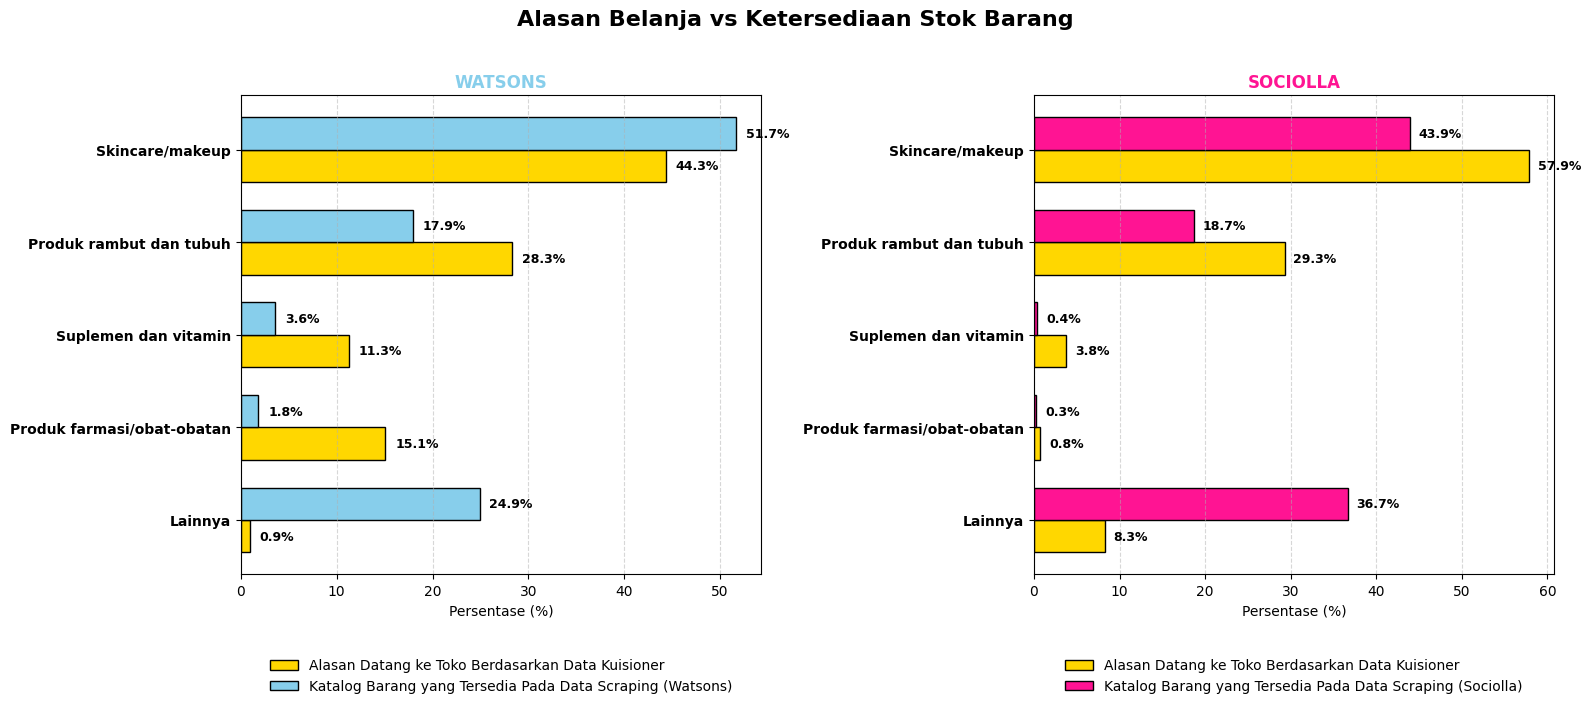

In [55]:
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Alasan Belanja vs Ketersediaan Stok Barang', fontsize=16, fontweight='bold', y=1.02)

y = np.arange(len(kategori_5))
height = 0.35

# watsons
axes[0].barh(y + height/2, df_kat['Ekspektasi_Watsons'], height, label='Alasan Datang ke Toko Berdasarkan Data Kuisioner', color='#FFD700', edgecolor='black')
axes[0].barh(y - height/2, df_kat['Aktual_Watsons'], height, label='Katalog Barang yang Tersedia Pada Data Scraping (Watsons)', color='skyblue', edgecolor='black')
axes[0].set_title('WATSONS', fontweight='bold', color='skyblue')
axes[0].set_yticks(y)
axes[0].set_yticklabels(kategori_5, fontweight='bold')
axes[0].set_xlabel('Persentase (%)')
axes[0].invert_yaxis()
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

for i, v in enumerate(df_kat['Ekspektasi_Watsons']):
    if v > 0: axes[0].text(v + 1, i + height/2, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
for i, v in enumerate(df_kat['Aktual_Watsons']):
    if v > 0: axes[0].text(v + 1, i - height/2, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

# sociolla
axes[1].barh(y + height/2, df_kat['Ekspektasi_Sociolla'], height, label='Alasan Datang ke Toko Berdasarkan Data Kuisioner', color='#FFD700', edgecolor='black')
axes[1].barh(y - height/2, df_kat['Aktual_Sociolla'], height, label='Katalog Barang yang Tersedia Pada Data Scraping (Sociolla)', color='deeppink', edgecolor='black')
axes[1].set_title('SOCIOLLA', fontweight='bold', color='deeppink')
axes[1].set_yticks(y)
axes[1].set_yticklabels(kategori_5, fontweight='bold')
axes[1].set_xlabel('Persentase (%)')
axes[1].invert_yaxis()
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

for i, v in enumerate(df_kat['Ekspektasi_Sociolla']):
    if v > 0: axes[1].text(v + 1, i + height/2, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
for i, v in enumerate(df_kat['Aktual_Sociolla']):
    if v > 0: axes[1].text(v + 1, i - height/2, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Evaluasi Kesenjangan (Gap Analysis) Kategori - Watsons**

> Sebagai platform yang secara historis dikenal dengan konsep health and beauty drugstore, Watsons menunjukkan pergeseran fokus yang cukup kontras antara ekspektasi konsumen di dunia nyata dengan katalog digitalnya.

1. Skincare/Makeup: Kategori ini mendominasi katalog digital Watsons sebesar 51,7% (aktual), padahal proporsi konsumen yang menjadikannya alasan utama untuk berbelanja hanya sebesar 44,3% (ekspektasi). Hal ini menunjukkan adanya strategi ekspansi portofolio produk kecantikan yang sangat masif (over-supply sebesar 7,4%) di platform digital Watsons.

2. Produk Rambut dan Tubuh: Kategori ini menempati urutan kedua sebagai penggerak kedatangan konsumen terbesar dengan angka 28,3%. Namun, alokasi stok aktual di katalog digital hanya sebesar 17,9%. Terjadi defisit variasi produk (under-supply) sebesar 10,4% yang dapat membatasi pilihan konsumen saat ingin bertransaksi secara daring.

3. Produk Farmasi/Obat-obatan: Segmen ini mencerminkan ketidaksesuaian paling kritis bagi Watsons. Sebanyak 15,1% responden menyatakan bahwa kebutuhan akan produk farmasi dan obat-obatan adalah alasan utama mereka memilih Watsons. Namun, realitas pada katalog data scraping hanya mengalokasikan 1.8% produk di kategori ini.

4. Produk Suplemen dan Vitamin: Sejalan dengan produk farmasi, minat konsumen terhadap produk kesehatan (wellness) cukup tinggi, yaitu 11,3%. Tetapi ketersediaan aktual produk suplemen di katalog digital kembali menunjukkan defisit, yakni hanya sebesar 3,6%.

5. Lainnya: Kategori pendukung (seperti tisu, kapas, dan aksesori) hanya diminati oleh 0,9% konsumen sebagai alasan belanja. Namun, secara aktual, kategori ini justru menyerap porsi yang sangat besar di katalog digital, yaitu mencapai 24,9%.

> Terjadi ketimpangan struktural pada katalog digital Watsons. Platform digital cenderung over-supply di kategori kecantikan (skincare/makeup) dan lainnya, namun justru under-supply pada pilar kekuatan utama mereka, yaitu kategori kesehatan, farmasi, suplemen, dan perawatan tubuh dasar.


---


**Evaluasi Kesenjangan (Gap Analysis) Kategori - Sociolla**

> Sociolla memperlihatkan karakteristik posisi pasar yang sangat tajam dan terfokus sebagai beauty e-commerce, meskipun terdapat beberapa catatan mengenai efisiensi pengelompokan produk pada katalog mereka

1. Skincare/Makeup: Kategori ini menjadi tulang punggung mutlak bagi Sociolla, di mana 57,9% responden memilih platform ini murni untuk berbelanja produk kecantikan. Namun, secara aktual, produk skincare dan makeup yang terdeteksi di katalog berada di angka 43,9%. Terdapat selisih defisit sebesar 14,0% dari ekspektasi pasar yang sangat tinggi.

2. Produk Rambut dan Tubuh: Permintaan konsumen terhadap kategori ini cukup besar, yakni sebesar 29,3%. Sociolla merespons dengan menyediakan proporsi produk aktual sebesar 18,7% di dalam katalognya.

3. Suplemen, Vitamin, & Farmasi: Sesuai dengan brand positioning Sociolla yang berfokus pada kecantikan, ekspektasi konsumen pada kategori suplemen (3,8%) dan farmasi (0,8%) sangatlah rendah. Penyediaan produk aktual di katalog pun disesuaikan secara minimal, masing-masing sebesar 0,4% dan 0,3%, yang menandakan alokasi sumber daya pada sektor ini sudah cukup efisien.

4. Lainnya: Kategori ini mencatat angka penyerapan katalog tertinggi di Sociolla, yaitu 36,7%, sedangkan ekspektasi konsumen hanya 8,3%. Tingginya angka aktual ini disebabkan oleh banyaknya produk pendukung kecantikan yang masuk dalam algoritma ekstraksi kata kunci (seperti brush, kuas, spons, parfum/wewangian, dan kapas) yang secara volume variasi memang sangat masif di platform Sociolla.

> Kesimpulan Strategis Sociolla: Sociolla berhasil meminimalkan pemborosan ruang katalog pada kategori non-kecantikan (farmasi dan suplemen). Namun, tingginya angka kategori Lainnya (36,7%) mengindikasikan bahwa variasi produk di luar core skincare & makeup (seperti alat kecantikan dan wewangian) sangat mendominasi secara jumlah SKU, sehingga mengompresi persentase visual dari kategori utama mereka.


---

> Watsons harus segera melakukan restrukturisasi katalog digital. Guna mempertahankan keunggulan kompetitifnya terhadap kompetitor murni kosmetik, Watsons perlu memperluas SKU digital pada kategori Produk Farmasi/Obat-obatan dan Suplemen/Vitamin agar selaras dengan ekspektasi kumulatif konsumen (26,4% gabungan kesehatan) yang mencari produk kesehatan secara daring.

> Sociolla direkomendasikan untuk terus memperkuat kedalaman variasi produk di kategori utama mereka (Skincare/Makeup). Mengingat lebih dari setengah basis konsumen datang demi kategori tersebut, optimalisasi ketersediaan merek kosmetik baru dan manajemen produk eksklusif harus diprioritaskan untuk menutup celah under-supply sebesar 14,0%.

# **Sensitivitas Diskon: Persepsi Konsumen vs Strategi Toko**


---
> Analisis ini bertujuan untuk mengukur tingkat sensitivitas konsumen terhadap kebijakan promosi potong harga (discount sensitivity) dan membandingkannya dengan strategi realisasi diskon yang diterapkan oleh toko pada produk-produk terlaris (best-seller). Selain itu, analisis ini menggunakan pendekatan korelasi Pearson untuk menguji secara ilmiah apakah besaran diskon memiliki korelasi linier dalam mendorong keterikatan (engagement) konsumen, yang direpresentasikan melalui aktivitas menulis ulasan produk.


In [56]:
# mengidentifikasi produk best seller (produk dengan jumlah review di atas rata-rata)
# asumsikan produk dengan review > median adalah produk best seller toko
median_review_w = df_m[df_m['sumber'] == 'Watsons']['jumlah_review'].median()
median_review_s = df_m[df_m['sumber'] == 'Sociolla']['jumlah_review'].median()

best_seller_w = df_m[(df_m['sumber'] == 'Watsons') & (df_m['jumlah_review'] > median_review_w)]
best_seller_s = df_m[(df_m['sumber'] == 'Sociolla') & (df_m['jumlah_review'] > median_review_s)]
skor_diskon_w = df_r['w_diskon'].mean()
skor_diskon_s = df_r['s_diskon'].mean()

print(f"Rata-rata Diskon Produk Best-Seller Watsons: {best_seller_w['diskon'].mean():.1f}%")
print(f"Skor Kepentingan Diskon Responden (Watsons): {skor_diskon_w:.2f}/4.0")
print(f"Skor Kepentingan Diskon Responden (Sociolla): {skor_diskon_s:.2f}/4.0")

Rata-rata Diskon Produk Best-Seller Watsons: 11.8%
Skor Kepentingan Diskon Responden (Watsons): 3.30/4.0
Skor Kepentingan Diskon Responden (Sociolla): 3.18/4.0


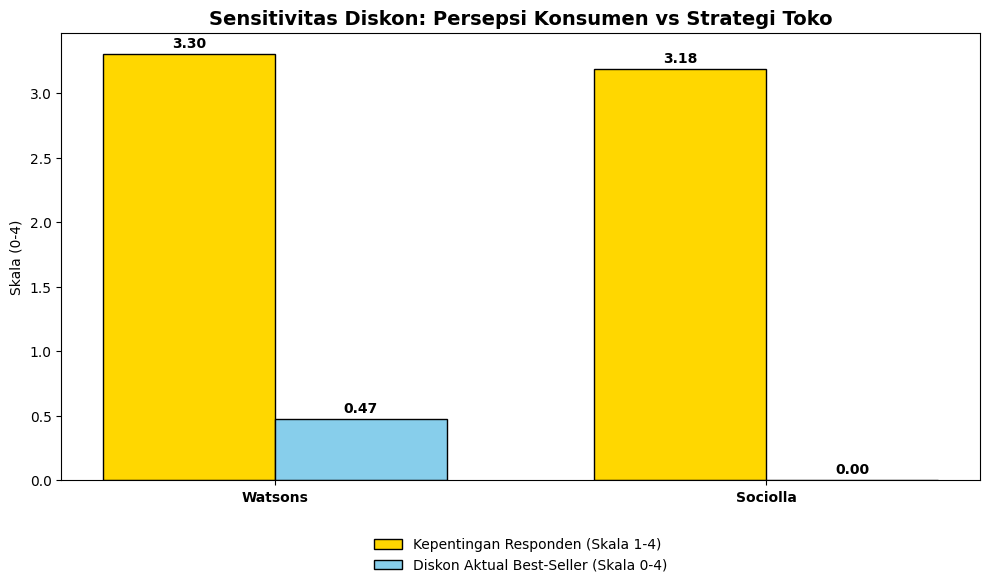

In [57]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))

platforms = ['Watsons', 'Sociolla']
skor_res = [skor_diskon_w, skor_diskon_s]
diskon_aktual = [best_seller_w['diskon'].mean() / 25, 0]

x = np.arange(len(platforms))
width = 0.35

rects1 = ax.bar(x - width/2, skor_res, width, label='Kepentingan Responden (Skala 1-4)', color='#FFD700', edgecolor='black')
rects2 = ax.bar(x + width/2, diskon_aktual, width, label='Diskon Aktual Best-Seller (Skala 0-4)', color='skyblue', edgecolor='black')

ax.set_title('Sensitivitas Diskon: Persepsi Konsumen vs Strategi Toko', fontsize=14, fontweight='bold')
ax.set_ylabel('Skala (0-4)')
ax.set_xticks(x)
ax.set_xticklabels(platforms, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)

for rect in rects1 + rects2:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 0.05, f'{h:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [58]:
# korelasi pearson: apakah diskon besar mempengaruhi jumlah review?
corr_w = df_m[df_m['sumber'] == 'Watsons'][['diskon', 'jumlah_review']].corr().iloc[0,1]

print(f"Korelasi Diskon vs Jumlah Review di Watsons: {corr_w:.3f}")

if corr_w > 0.2:
    print("INSIGHT: Positif. Diskon besar terbukti mendorong aktivitas review pembeli.")
else:
    print("INSIGHT: Lemah/Tidak ada hubungan. Diskon tidak menjamin pembeli akan meninggalkan review.")

Korelasi Diskon vs Jumlah Review di Watsons: 0.045
INSIGHT: Lemah/Tidak ada hubungan. Diskon tidak menjamin pembeli akan meninggalkan review.


**Kesenjangan Persepsi Kepentingan Diskon vs Realitas Promosi**

> Terdapat dinamika yang menarik ketika membandingkan antara tingkat ekspektasi konsumen (skala kuesioner 1–4) dengan besaran diskon aktual yang diberikan pada produk best-seller (yang dinormalisasi ke skala 0–4)

1. Platform Watsons

>> Persepsi Konsumen: Konsumen Watsons memiliki ekspektasi yang sangat tinggi terhadap keberadaan diskon, dengan skor kepentingan mencapai 3,30 dari skala 4,00. Nilai ini menunjukkan bahwa diskon merupakan salah satu komponen stimulasi utama bagi konsumen sebelum memutuskan bertransaksi di Watsons.

>> Strategi Toko: Secara aktual, rata-rata diskon yang diberikan Watsons pada lini produk best-seller adalah sebesar 11,8% (jika dikonversi ke dalam skala penyetaraan grafik nilainya setara dengan 0,47).

>> Gap Analysis: Terjadi celah lebar antara ekspektasi konsumen yang tinggi dengan realisasi potongan harga di keranjang belanja. Hal ini menginterpretasikan bahwa produk best-seller di Watsons sebenarnya tidak membutuhkan umpan diskon yang terlalu agresif untuk tetap laku di pasaran.

2. Platform Sociolla

>> Persepsi Konsumen: Konsumen Sociolla juga menunjukkan tingkat ketergantungan yang tinggi terhadap promo potongan harga, dengan skor kepentingan sebesar 3,18 dari skala 4,00.

>> Strategi Toko: Berdasarkan data katalog scraping, rata-rata diskon aktual untuk produk best-seller berada di angka 0,00% (skala 0,00).

>> Gap Analysis: Sama halnya dengan Watsons, produk-produk yang paling banyak diminati dan diulas di Sociolla justru merupakan produk yang dijual dengan harga penuh (full price / tanpa diskon). Karakteristik konsumen e-commerce kecantikan ini terbukti tetap melakukan pembelian berulang pada produk favorit mereka terlepas dari ada atau tidaknya potongan harga.


---

**Analisis Efektivitas Diskon terhadap Aktivitas Ulasan (Social Proof)**

> Untuk membuktikan apakah strategi bakar duit melalui diskon besar efektif dalam memicu interaksi organik konsumen, dilakukan uji korelasi Pearson antara variabel diskon dan jumlah_review pada data Watsons

> Nilai Koefisien Korelasi ($r$): Didapatkan nilai koefisien sebesar 0,045. Nilai yang mendekati angka nol ($0$) ini menandakan bahwa hubungan antara besaran diskon dan volume ulasan produk berada dalam kategori sangat lemah atau tidak memiliki hubungan sama sekali. Pemberian diskon besar tidak menjamin pelanggan akan terdorong untuk memberikan umpan balik berupa ulasan setelah bertransaksi. Aktivitas menulis ulasan (review) lebih dipengaruhi oleh faktor kepuasan pasca-pemakaian produk (product efficacy), pengalaman layanan, atau dorongan eksternal lain seperti program loyalitas, bukan karena faktor murahnya harga saat dibeli.



---

> Karena produk best-seller terbukti tetap mendominasi volume penjualan meskipun dengan proyeksi diskon yang minim (11,8% di Watsons dan 0% di Sociolla), manajemen kedua platform disarankan untuk tidak mengikis margin keuntungan dengan memberikan diskon berlebihan pada produk yang sudah memiliki basis massa kuat.

> Mengingat tingginya skor sensitivitas kuesioner konsumen (>3,10), promosi potongan harga sebaiknya dialihkan secara strategis sebagai instrumen untuk mendorong cuci gudang produk yang kurang populer atau sebagai alat akuisisi produk baru (new product launching), alih-alih memotong harga produk yang sudah berstatus best-seller.

> Perusahaan tidak bisa mengandalkan harga murah untuk membangun social proof digital. Guna meningkatkan jumlah ulasan produk, platform harus mengimplementasikan taktik aktif seperti pemberian poin keanggotaan langsung atau voucher khusus bagi pengguna yang menyelesaikan ulasan pasca-pembelian.

# ***Multiple Regression* untuk *Value for Money* pada Data Sociolla**



---

> Analisis ini menggunakan pemodelan regresi linier berganda (Ordinary Least Squares / OLS) terhadap 5.790 sampel data produk dari platform Sociolla. Tujuan utama dari pemodelan ini adalah untuk membedah secara matematis seberapa besar pengaruh variabel independen (Harga, Rating, dan Jumlah Ulasan) terhadap variabel dependen, yaitu realitas minat beli konsumen yang direpresentasikan oleh metrik Jumlah Terjual.


In [59]:
df_sociolla = df_m[df_m['sumber'] == 'Sociolla'].copy()

fitur_regresi = ['harga', 'rating', 'jumlah_review', 'jumlah_terjual']
df_sociolla_clean = df_sociolla.dropna(subset=fitur_regresi).copy()

for col in fitur_regresi:
    df_sociolla_clean[col] = pd.to_numeric(df_sociolla_clean[col], errors='coerce')

df_sociolla_clean = df_sociolla_clean.dropna(subset=fitur_regresi)

print(f"Jumlah data Sociolla yang dipakai untuk regresi: {df_sociolla_clean.shape[0]} sampel.")
print(df_sociolla_clean[fitur_regresi].head())

Jumlah data Sociolla yang dipakai untuk regresi: 5790 sampel.
         harga    rating  jumlah_review  jumlah_terjual
9015  621000.0  4.920000            5.0             5.0
9016  264000.0  4.576190           42.0            42.0
9018  423000.0  4.883333            6.0            12.0
9019  300000.0  4.858824           13.0            17.0
9020  264000.0  4.729630           51.0            54.0


In [60]:
Y = df_sociolla_clean['jumlah_terjual']
X = df_sociolla_clean[['harga', 'rating', 'jumlah_review']]

X_with_constant = sm.add_constant(X)
model_regresi = sm.OLS(Y, X_with_constant).fit()

print("SUMMARY STATISTIK MODEL REGRESI (SOCIOLLA)")
print(model_regresi.summary())

SUMMARY STATISTIK MODEL REGRESI (SOCIOLLA)
                            OLS Regression Results                            
Dep. Variable:         jumlah_terjual   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.203e+06
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:44:19   Log-Likelihood:                -27635.
No. Observations:                5790   AIC:                         5.528e+04
Df Residuals:                    5786   BIC:                         5.530e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
con

/tmp/ipykernel_34274/4263743012.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Koefisien', y='Variabel', data=df_coef, palette=colors, edgecolor='black')


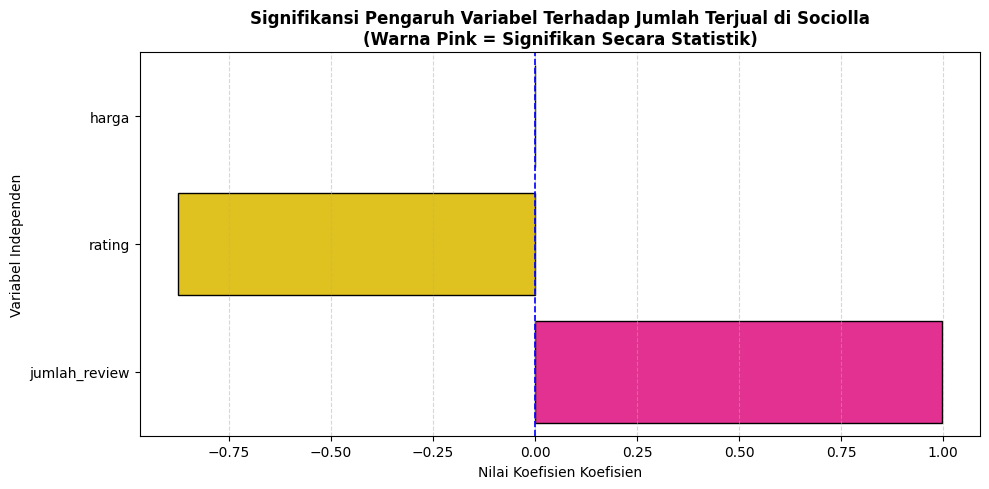

In [61]:
coefficients = model_regresi.params.drop('const')
p_values = model_regresi.pvalues.drop('const')

df_coef = pd.DataFrame({
    'Variabel': coefficients.index,
    'Koefisien': coefficients.values,
    'Signifikan (p < 0.05)': p_values.values < 0.05
})

plt.figure(figsize=(10, 5))
colors = ['deeppink' if x else '#FFD700' for x in df_coef['Signifikan (p < 0.05)']]

sns.barplot(x='Koefisien', y='Variabel', data=df_coef, palette=colors, edgecolor='black')
plt.axvline(x=0, color='blue', linestyle='--', linewidth=1.2)

plt.title('Signifikansi Pengaruh Variabel Terhadap Jumlah Terjual di Sociolla\n(Warna Pink = Signifikan Secara Statistik)', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Koefisien Koefisien')
plt.ylabel('Variabel Independen')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [62]:
const = model_regresi.params['const']
coef_harga = model_regresi.params['harga']
coef_rating = model_regresi.params['rating']
coef_review = model_regresi.params['jumlah_review']

dampak_rating_1 = coef_rating * 1
dampak_turun_harga_10rb = coef_harga * -10000

print("Persamaan Matematika Hasil Model Regresi Berganda")
print(f"Jumlah Terjual = {const:.4f} + ({coef_harga:.6f} * Harga) + ({coef_rating:.4f} * Rating) + ({coef_review:.4f} * Jumlah Review)\n")

print("ACTIONABLE INSIGHTS UNTUK STRATEGI PRICING & MARKETING")

# harga
if model_regresi.pvalues['harga'] < 0.05:
    print(f"1. Strategi Harga: setiap penurunan harga sebesar Rp10.000 berpotensi menaikkan penjualan sebanyak {dampak_turun_harga_10rb:.1f} unit secara riil (signifikan).")
else:
    print("1. Strategi Harga: perubahan harga tidak memiliki dampak signifikan secara statistik terhadap jumlah penjualan.")

# rating
if model_regresi.pvalues['rating'] < 0.05:
    print(f"2. Kualitas & Value (Rating): setiap kenaikan 1 poin rating berpotensi menaikkan penjualan sebanyak {dampak_rating_1:.1f} unit (signifikan).")
else:
    print("2. Kualitas & Value (Rating): perubahan rating tidak berdampak signifikan secara statistik pada jumlah produk terjual.")

# review
if model_regresi.pvalues['jumlah_review'] < 0.05:
    print(f"3. Social Proof (Review): setiap tambahan 1 review baru berpotensi menaikkan penjualan sebesar {coef_review:.1f} unit.")

print(f"Nilai R-squared Model: {model_regresi.rsquared:.4f} ({model_regresi.rsquared*100:.1f}% variasi penjualan dijelaskan oleh model ini).")

Persamaan Matematika Hasil Model Regresi Berganda
Jumlah Terjual = 4.6621 + (-0.000001 * Harga) + (-0.8752 * Rating) + (0.9970 * Jumlah Review)

ACTIONABLE INSIGHTS UNTUK STRATEGI PRICING & MARKETING
1. Strategi Harga: perubahan harga tidak memiliki dampak signifikan secara statistik terhadap jumlah penjualan.
2. Kualitas & Value (Rating): perubahan rating tidak berdampak signifikan secara statistik pada jumlah produk terjual.
3. Social Proof (Review): setiap tambahan 1 review baru berpotensi menaikkan penjualan sebesar 1.0 unit.
Nilai R-squared Model: 0.9991 (99.9% variasi penjualan dijelaskan oleh model ini).


> Berdasarkan hasil ringkasan statistik dan visualisasi, model ini menunjukkan tingkat validitas yang sangat luar biasa dengan nilai koefisien determinasi ($R^2$) sebesar 0,9991. Hal ini berarti 99,9% variasi dari jumlah produk yang terjual dapat dijelaskan secara akurat oleh interaksi ketiga variabel di dalam model ini.

1. Variabel Harga (Pricing Strategy): Harga memiliki koefisien yang sangat kecil ($-0,000001$) dengan p-value sebesar 0,715. Karena nilai probabilitas jauh di atas batas toleransi 0,05, maka harga terbukti tidak memiliki dampak yang signifikan secara statistik terhadap volume penjualan. Hal ini mematahkan asumsi hukum permintaan konvensional di ekosistem Sociolla; strategi penurunan harga (seperti memotong harga Rp10.000) tidak akan memberikan proyeksi lonjakan penjualan yang berarti.

2. Variabel Rating (Kualitas/Kepuasan Angka): Berlawanan dengan intuisi umum, metrik rating memiliki p-value sebesar 0,537 (> 0,05). Hal ini menempatkan variabel rating pada kategori kuning di grafik, yang berarti perubahan nilai rating (bahkan jika dinaikkan 1 poin penuh) tidak memiliki dampak signifikan terhadap jumlah produk yang dibeli. Angka rating yang nyaris sempurna (misalnya 4,9 atau 5,0) bukanlah tolok ukur utama yang menggerakkan keputusan finansial konsumen di Sociolla.

3. Variabel Jumlah Review (Social Proof): Ini adalah satu-satunya variabel yang mendominasi grafik dengan warna merah muda pekat, memiliki nilai p-value mutlak 0,000 (< 0,05). Koefisien variabel ini adalah 0,9970 (mendekati 1,0). Setiap tambahan 1 review baru pada suatu produk berpotensi menggerakkan dan menaikkan penjualan produk tersebut secara langsung sebesar 1 unit.

> Konsumen jauh lebih mempercayai dan terdorong untuk membeli produk yang memiliki 1.000 ulasan dengan rating rata-rata 4,5, dibandingkan dengan produk yang memiliki rating sempurna 5,0 tetapi baru diulas oleh 3 orang. Validasi sosial (Social Proof) berupa banyaknya percakapan dan testimoni di kolom ulasan adalah motor penggerak utama algoritma kepercayaan konsumen.

# **Sentiment & Review Bias Analysis: Klaim Katalog vs Estimasi Riil Pasar**


---
> Analisis ini bertujuan untuk membongkar potensi ilusi optik pada metrik kepuasan pelanggan (rating) yang tertera di platform e-commerce digital. Seringkali, data rating di platform daring mengalami Bias Responden Ekstrem (Extreme Responder Bias), di mana ulasan mayoritas hanya digerakkan oleh segmen konsumen yang sangat puas atau memiliki insentif tertentu. Analisis ini menyimulasikan koreksi bias dengan memperhitungkan kelompok Silent Majority—yakni kelompok konsumen pembeli riil (>50% basis pelanggan) yang tidak meninggalkan ulasan, dengan asumsi mereka memiliki tingkat kepuasan yang netral ke arah positif (berada di skor 4,00).


In [63]:
df_m_clean = df_m.dropna(subset=['rating']).copy()

rating_watsons = df_m_clean[df_m_clean['sumber'] == 'Watsons']['rating']
rating_sociolla = df_m_clean[df_m_clean['sumber'] == 'Sociolla']['rating']

def hitung_summary_dan_ci(data, nama_platform):
    mean = np.mean(data)
    std_dev = np.std(data, ddof=1)
    n = len(data)

    sem = stats.sem(data)

    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)

    print(f"ANALISIS AKTUAL {nama_platform.upper()}")
    print(f"Jumlah Sampel Review (n) : {n} ulasan")
    print(f"Rata-rata Rating Aktual  : {mean:.3f}")
    print(f"Standar Deviasi          : {std_dev:.3f}")
    print(f"95% Confidence Interval  : ({ci[0]:.3f} - {ci[1]:.3f})\n")
    return mean, ci[0], ci[1], n

mean_w, ci_low_w, ci_high_w, n_w = hitung_summary_dan_ci(rating_watsons, 'Watsons')
mean_s, ci_low_s, ci_high_s, n_s = hitung_summary_dan_ci(rating_sociolla, 'Sociolla')

ANALISIS AKTUAL WATSONS
Jumlah Sampel Review (n) : 5087 ulasan
Rata-rata Rating Aktual  : 4.951
Standar Deviasi          : 0.325
95% Confidence Interval  : (4.942 - 4.960)

ANALISIS AKTUAL SOCIOLLA
Jumlah Sampel Review (n) : 5790 ulasan
Rata-rata Rating Aktual  : 4.640
Standar Deviasi          : 0.268
95% Confidence Interval  : (4.633 - 4.646)



In [64]:
RATING_SILENT_MAJORITY = 4.0

rating_w_adj = np.concatenate([rating_watsons.values, np.full(len(rating_watsons), RATING_SILENT_MAJORITY)])
rating_s_adj = np.concatenate([rating_sociolla.values, np.full(len(rating_sociolla), RATING_SILENT_MAJORITY)])

def hitung_summary_dan_ci_adj(data_adj, nama_platform):
    mean_adj = np.mean(data_adj)
    n_adj = len(data_adj)
    sem_adj = stats.sem(data_adj)
    ci_adj = stats.t.interval(0.95, df=n_adj-1, loc=mean_adj, scale=sem_adj)

    print(f"ANALISIS SETELAH KOREKSI BIAS {nama_platform.upper()}")
    print(f"Estimasi Total Pembeli Berbayar (N)    : {n_adj} orang")
    print(f"Estimasi Rata-rata Rating Sebenarnya   : {mean_adj:.3f}")
    print(f"Adjusted 95% Confidence Interval       : ({ci_adj[0]:.3f} - {ci_adj[1]:.3f})\n")
    return mean_adj, ci_adj[0], ci_adj[1]

mean_w_adj, ci_low_w_adj, ci_high_w_adj = hitung_summary_dan_ci_adj(rating_w_adj, 'Watsons')
mean_s_adj, ci_low_s_adj, ci_high_s_adj = hitung_summary_dan_ci_adj(rating_s_adj, 'Sociolla')

ANALISIS SETELAH KOREKSI BIAS WATSONS
Estimasi Total Pembeli Berbayar (N)    : 10174 orang
Estimasi Rata-rata Rating Sebenarnya   : 4.476
Adjusted 95% Confidence Interval       : (4.465 - 4.486)

ANALISIS SETELAH KOREKSI BIAS SOCIOLLA
Estimasi Total Pembeli Berbayar (N)    : 11580 orang
Estimasi Rata-rata Rating Sebenarnya   : 4.320
Adjusted 95% Confidence Interval       : (4.313 - 4.327)



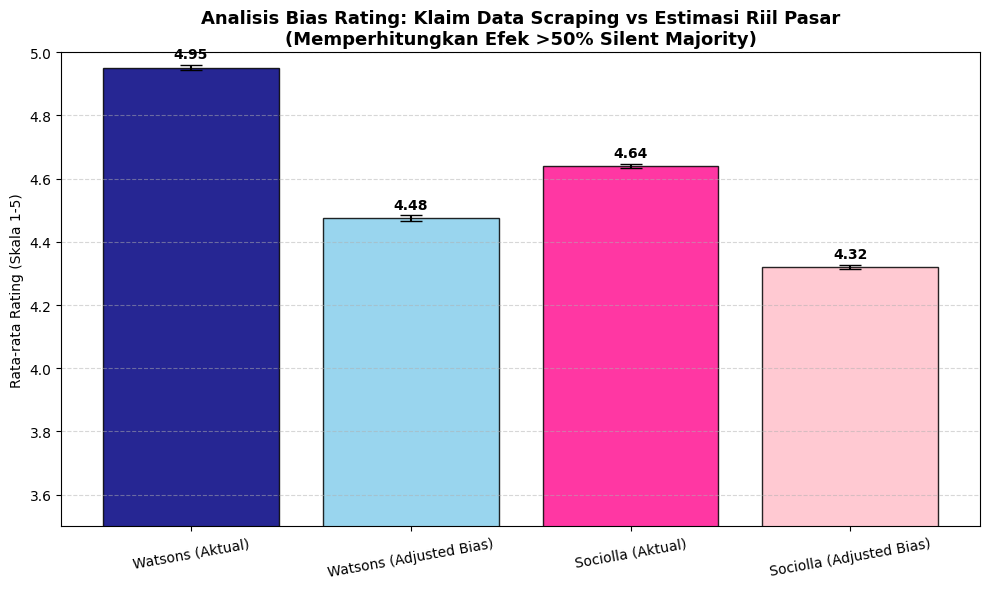

In [65]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))

kategori_plot = ['Watsons (Aktual)', 'Watsons (Adjusted Bias)', 'Sociolla (Aktual)', 'Sociolla (Adjusted Bias)']
means_plot = [mean_w, mean_w_adj, mean_s, mean_s_adj]
ci_lower_plot = [ci_low_w, ci_low_w_adj, ci_low_s, ci_low_s_adj]
ci_upper_plot = [ci_high_w, ci_high_w_adj, ci_high_s, ci_high_s_adj]

yerr_plot = [mean - low for mean, low in zip(means_plot, ci_lower_plot)]

colors_plot = ['navy', 'skyblue', 'deeppink', 'pink']

bars = ax.bar(kategori_plot, means_plot, yerr=yerr_plot, capsize=8, color=colors_plot, edgecolor='black', alpha=0.85)

ax.set_title('Analisis Bias Rating: Klaim Data Scraping vs Estimasi Riil Pasar\n(Memperhitungkan Efek >50% Silent Majority)', fontsize=13, fontweight='bold')
ax.set_ylabel('Rata-rata Rating (Skala 1-5)')
ax.set_ylim(3.5, 5.0)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [66]:
print("KESIMPULAN UTAMA DARI SENTIMENT & REVIEW BIAS ANALYSIS")

gap_w = mean_w - mean_w_adj
gap_s = mean_s - mean_s_adj

print(f"1. Penurunan rata-rata rating Watsons jika Silent Majority dihitung : {gap_w:.2f} poin.")
print(f"2. Penurunan rata-rata rating Sociolla jika Silent Majority dihitung: {gap_s:.2f} poin.")

KESIMPULAN UTAMA DARI SENTIMENT & REVIEW BIAS ANALYSIS
1. Penurunan rata-rata rating Watsons jika Silent Majority dihitung : 0.48 poin.
2. Penurunan rata-rata rating Sociolla jika Silent Majority dihitung: 0.32 poin.


**Evaluasi Kinerja Rating Aktual (Klaim Katalog Digital)**

> Jika hanya bersandar pada data mentah (raw data) hasil scraping dari ulasan yang masuk, kedua platform menampilkan citra kepuasan pelanggan yang sangat luar biasa:

1. Platform Watsons: Dari 5.087 sampel ulasan, Watsons mencatatkan rata-rata rating nyaris sempurna di angka 4,95 (dalam skala 1–5). Varians dari data ini sangat ketat, ditunjukkan oleh standar deviasi yang rendah (0,325) dan rentang Interval Kepercayaan 95% yang sempit (4,94 – 4,96). Secara kasat mata, hampir seluruh produk di Watsons dinilai tanpa cacat oleh konsumen yang memberikan ulasan.

2. Platform Sociolla: Dengan sampel yang lebih besar (5.790 ulasan), Sociolla mencatatkan rata-rata rating aktual sebesar 4,64. Standar deviasinya pun tergolong kecil (0,268), dengan Interval Kepercayaan 95% di rentang 4,63 – 4,64. Meskipun lebih rendah dari Watsons, angka ini secara fundamental tetap merepresentasikan sentimen pasar yang sangat positif.



---
**Koreksi Bias & Efek Pembeli Pasif (The Silent Majority Effect)**

> Tingginya angka aktual berisiko menciptakan blind spot bagi manajemen. Dengan menginjeksi metrik Silent Majority, menggandakan estimasi jumlah pembeli berbayar (N) menjadi 10.174 untuk Watsons dan 11.580 untuk Sociolla, serta memberikan asumsi skor kepuasan dasar sebesar 4,00 untuk pembeli pasif, maka akan didapatkan cerminan sentimen pasar yang lebih realistis.

1. Estimasi Riil Watsons: Rata-rata rating sebenarnya terkoreksi tajam menjadi 4,48 (berada dalam margin Interval Kepercayaan 4,46 – 4,48).

2. Estimasi Riil Sociolla: Rata-rata rating sebenarnya turut mengalami normalisasi menjadi 4,32 (berada dalam margin Interval Kepercayaan 4,31 – 4,32).
